In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datasets as df
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [1]:
# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/wine-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.45k/4.45k [00:00<00:00, 5.97MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tawfikelmetwally/wine-dataset/versions/2


In [7]:
# 1. CARICAMENTO DATI (13 feature chimiche per ogni vino)
df = pd.read_csv(path + "/Wine dataset.csv")
X = df.drop(columns=["class"]).values # features
y = df["class"].values # Tipi reali di vitigno (0, 1, 2) - usati SOLO per confronto finale!

In [8]:
# 2. STANDARDIZZAZIONE (Fase CRITICA per la PCA!)
# La PCA si basa sulla varianza: se una colonna ha numeri grandi (es. Prolina ~1000)
# e un'altra numeri piccoli (es. Magnesio ~0.1), la PCA si fa ingannare.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
# 3. PCA: Riduzione da 13D -> 2D
pca = PCA(n_components=2) # posso specificare il numero di componenti o la percentuale desiderata
X_pca = pca.fit_transform(X_scaled)

In [32]:
# Quanta informazione originale abbiamo mantenuto riducendo a 2D?
info_mantenuta = pca.explained_variance_ratio_.sum()
print(f"Informazione totale conservata nelle 2 componenti: {info_mantenuta:.2%}")

Informazione totale conservata nelle 2 componenti: 92.02%


In [33]:
# 4. ELBOW METHOD sullo spazio ridotto PCA
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

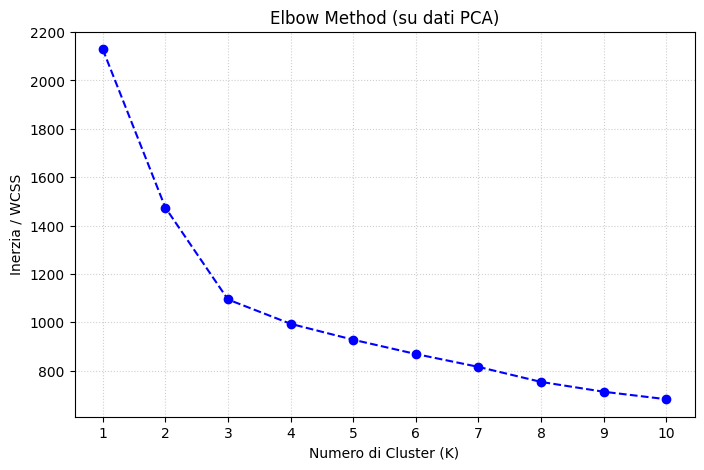

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--", color="b")

plt.title("Elbow Method (su dati PCA)")
plt.xlabel("Numero di Cluster (K)")
plt.ylabel("Inerzia / WCSS")
plt.xticks(range(1, 11))  # Mostra tutti i numeri da 1 a 10 sull'asse X
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [35]:
# 5. K-MEANS sulle 2 Componenti Principali
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

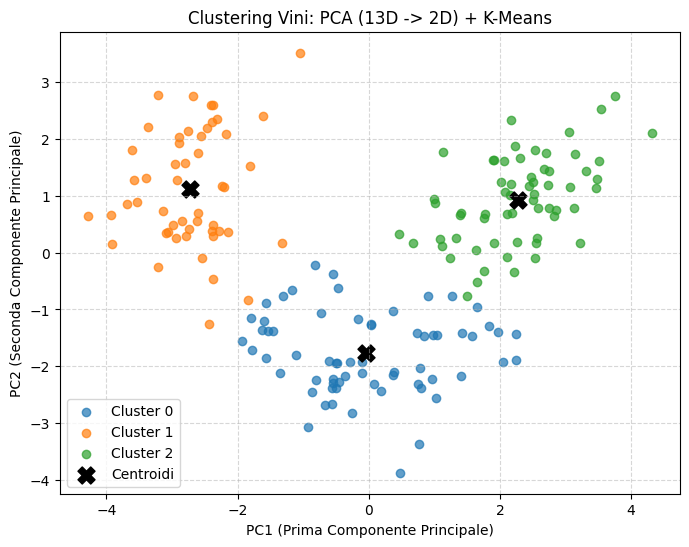

In [36]:
# 6. GRAFICO FINALE
plt.figure(figsize=(8, 6))
for i in range(3):
    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1],
        label=f"Cluster {i}",
        alpha=0.7,
    )

# Centroidi nello spazio PCA
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=150,
    c="black",
    marker="X",
    label="Centroidi",
)

plt.title("Clustering Vini: PCA (13D -> 2D) + K-Means")
plt.xlabel("PC1 (Prima Componente Principale)")
plt.ylabel("PC2 (Seconda Componente Principale)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [40]:
from sklearn.metrics import silhouette_score

# Calcolo sullo spazio ridotto dalla PCA e con le etichette trovate da K-Means
score = silhouette_score(X_pca, labels)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.558
